<a href="https://colab.research.google.com/github/Rakib911Hossan/ml-penta/blob/dev/deberta_emotion_details.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub captum bertviz

import os, re, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from collections import defaultdict
from tqdm.auto import tqdm


import transformers, tokenizers
from transformers import (
    AutoTokenizer, AutoModel, AutoConfig, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup,
)

import torch
import torch.nn as nn
from torch.nn import Parameter
import torch.nn.functional as F
from torch.optim import Adam, SGD, AdamW
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils import resample

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

print(f"transformers : {transformers.__version__}")
print(f"torch        : {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device       : {DEVICE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.4 MB/s eta 0:00:00
transformers : 5.0.0
torch        : 2.10.0+cu128
Device       : cuda


In [ ]:
class CFG:
    model_name       = "microsoft/deberta-v3-base"
    num_labels       = 5

    apex=True

    epochs           = 6
    batch_size       = 32
    learning_rate    = 2e-5
    weight_decay     = 0.01
    warmup_steps     = 200
    max_grad_norm    = 1.0

    eps=1e-6
    betas=(0.9, 0.999)

    test_size        = 0.20
    gradient_accumulation_steps=1

    train=True

    seed             = 42
    output_dir       = "./results"
    save_dir         = "./deberta_emotion_model"


def seed_everything(seed):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(CFG.seed)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("pashupatigupta/emotion-detection-from-text")
print("Files:", os.listdir(path))

df = pd.read_csv(f"{path}/tweet_emotions.csv")
print("Shape:", df.shape)
print("Unique sentiments:", sorted(df['sentiment'].unique()))
df.head()

Using Colab cache for faster access to the 'emotion-detection-from-text' dataset.
Files: ['tweet_emotions.csv']
Shape: (40000, 3)
Unique sentiments: ['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']


,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


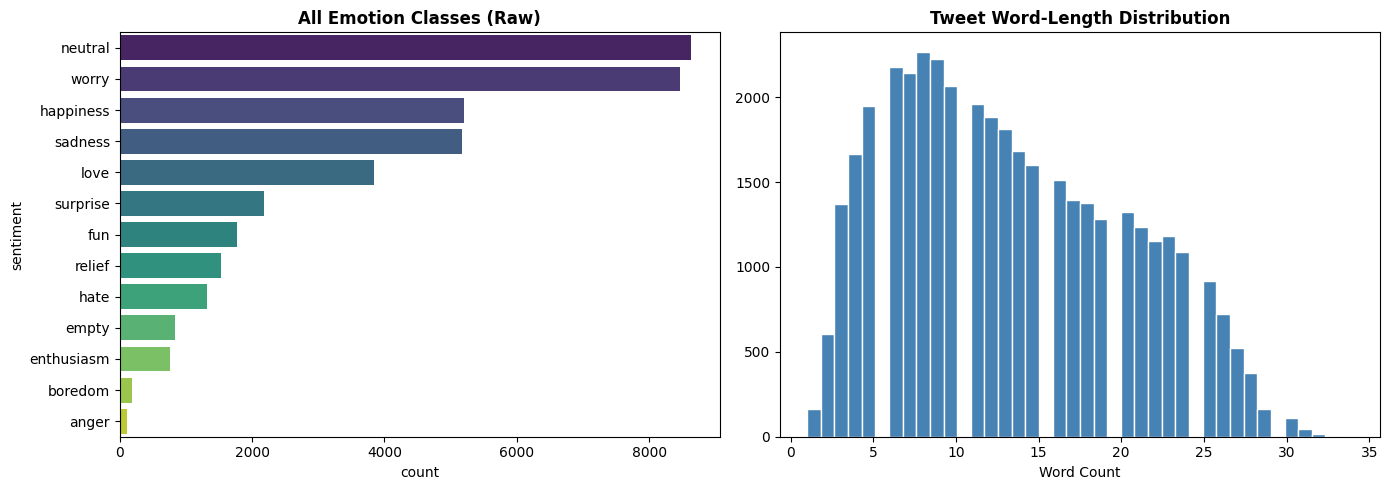

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
order_all = df['sentiment'].value_counts().index
sns.countplot(y='sentiment', data=df, order=order_all,
              palette='viridis', ax=axes[0])
axes[0].set_title('All Emotion Classes (Raw)', fontweight='bold')

# Tweet length distribution
df['text_length'] = df['content'].astype(str).apply(lambda x: len(x.split()))
axes[1].hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Tweet Word-Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()
print(df['sentiment'].value_counts())

In [ ]:
def preprocess(text: str) -> str:
    text = str(text)
    text = re.sub(r'@\w+', '', text)           # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

df['clean_text'] = df['content'].apply(preprocess)
print(df[['content', 'clean_text', 'sentiment']].head(8).to_string())

                                                                                                                                content                                                                                                                            clean_text   sentiment
0                                          @tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =[                                                       i know i was listenin to bad habit earlier and i started freakin at his part =[       empty
1                                                                          Layin n bed with a headache  ughhhh...waitin on your call...                                                                           Layin n bed with a headache ughhhh...waitin on your call...     sadness
2                                                                                                   Funeral ceremony...gloomy friday...                   

In [ ]:
top_emotions = ['neutral', 'worry', 'happiness', 'sadness', 'love']

df = df[df['sentiment'].isin(top_emotions)].copy()
df['sentiment_grouped'] = df['sentiment']
print("Before balancing:\n", df['sentiment_grouped'].value_counts())

Before balancing:
 sentiment_grouped
neutral      8638
worry        8459
happiness    5209
sadness      5165
love         3842
Name: count, dtype: int64


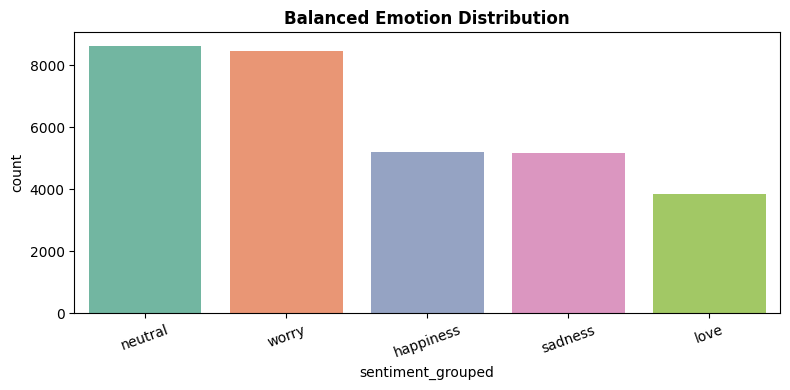

In [ ]:
# Plot
plt.figure(figsize=(8, 4))
sns.countplot(x='sentiment_grouped', data=df,
              order=df['sentiment_grouped'].value_counts().index,
              palette='Set2')
plt.title('Balanced Emotion Distribution', fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
min_words = 2
X = df['clean_text']
Y = df['sentiment_grouped']

X_train_dev, X_test, Y_train_dev, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=CFG.seed, stratify=Y
)
X_train, X_dev, Y_train, Y_dev = train_test_split(
    X_train_dev, Y_train_dev, test_size=0.25, random_state=CFG.seed, stratify=Y_train_dev
)

# Convert to string and remove NaN
X_train = X_train.fillna("").astype(str)
X_dev   = X_dev.fillna("").astype(str)
X_test  = X_test.fillna("").astype(str)

# Drop very short samples
mask_train = X_train.str.split().apply(len) >= min_words
mask_dev   = X_dev.str.split().apply(len)   >= min_words
mask_test  = X_test.str.split().apply(len)  >= min_words

X_train = X_train[mask_train].reset_index(drop=True)
Y_train = Y_train[mask_train].reset_index(drop=True)
X_dev   = X_dev[mask_dev].reset_index(drop=True)
Y_dev   = Y_dev[mask_dev].reset_index(drop=True)
X_test  = X_test[mask_test].reset_index(drop=True)
Y_test  = Y_test[mask_test].reset_index(drop=True)

print(f"Train: {len(X_train)} | Dev: {len(X_dev)} | Test: {len(X_test)}")

# Label encoding
le = LabelEncoder()
le.fit(Y)
Y_train_enc = le.transform(Y_train)
Y_dev_enc = le.transform(Y_dev)
Y_test_enc  = le.transform(Y_test)

id2label = {i: lbl for i, lbl in enumerate(le.classes_)}
label2id = {lbl: i for i, lbl in id2label.items()}
CFG.num_labels = len(le.classes_)

print("Label mapping:", id2label)

Train: 18557 | Dev: 6193 | Test: 6181
Label mapping: {0: 'happiness', 1: 'love', 2: 'neutral', 3: 'sadness', 4: 'worry'}


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)

token_lengths = X_train.apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

print(token_lengths.describe())

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

count    18557.000000
mean        17.145605
std          9.557855
min          2.000000
25%          9.000000
50%         16.000000
75%         24.000000
max         97.000000
Name: clean_text, dtype: float64


In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=128
        )

        return {
            'input_ids': encoding['input_ids'],
            'attention_mask': encoding['attention_mask'],
            'labels': self.labels[idx]
        }


train_dataset = EmotionDataset(X_train, Y_train_enc)
dev_dataset   = EmotionDataset(X_dev,   Y_dev_enc)
test_dataset  = EmotionDataset(X_test,  Y_test_enc)

print(f"Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)}")


Train: 18557 | Dev: 6193 | Test: 6181


In [ ]:
dev_dataset.__getitem__(2)

{'input_ids': [4385,
  608,
  3447,
  351,
  393,
  673,
  22118,
  6438,
  8476,
  18201,
  461,
  400,
  7025,
  429,
  10832,
  346,
  974,
  10832,
  346,
  98741,
  1204,
  592],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'labels': np.int64(0)}

In [ ]:
# class DeBERTaForEmotionClassification(nn.Module):
#     def __init__(self, model_name, num_labels):
#         super().__init__()

#         self.config = AutoConfig.from_pretrained(
#             model_name,
#             output_hidden_states=True,
#             output_attentions=True
#         )
#         # disable dropouts for stable fine-tuning
#         self.config.hidden_dropout_prob         = 0.16
#         self.config.attention_probs_dropout_prob = 0.16

#         self.deberta  = AutoModel.from_pretrained(model_name, config=self.config)
#         self.dropout  = nn.Dropout(0.1)
#         self.classifier = nn.Linear(self.config.hidden_size, num_labels)

#     # def forward(self, input_ids, attention_mask):
#     #     outputs = self.deberta(
#     #         input_ids=input_ids,
#     #         attention_mask=attention_mask
#     #     )
#     #     # [CLS] token representation from last hidden state
#     #     cls_output = outputs.last_hidden_state[:, 0, :]   # (batch, hidden_size)
#     #     cls_output = self.dropout(cls_output)
#     #     logits     = self.classifier(cls_output)           # (batch, num_labels)
#     #     attentions = outputs.attentions                    # all layer attentions

#     #     return logits, attentions
#     def forward(self, input_ids, attention_mask):
#         outputs = self.deberta(input_ids=input_ids, attention_mask=attention_mask)

#         # Mean pooling instead of CLS
#         hidden = outputs.last_hidden_state  # (batch, seq_len, hidden)
#         mask = attention_mask.unsqueeze(-1).float()
#         pooled = (hidden * mask).sum(1) / mask.sum(1)  # (batch, hidden)

#         pooled = self.dropout(pooled)
#         logits = self.classifier(pooled)
#         attentions = outputs.attentions
#         return logits, attentions


class DeBERTaForEmotionClassification(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()

        self.config = AutoConfig.from_pretrained(
            model_name,
            output_hidden_states=True,
            output_attentions=True
        )
        self.config.hidden_dropout_prob          = 0.16
        self.config.attention_probs_dropout_prob = 0.16

        self.deberta    = AutoModel.from_pretrained(model_name, config=self.config)
        self.dropout    = nn.Dropout(0.2)
        self.fc1        = nn.Linear(self.config.hidden_size, 512)
        self.gelu       = nn.GELU()
        self.layer_norm = nn.LayerNorm(512)
        self.fc2        = nn.Linear(512, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.deberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.fc1(cls_output)
        x = self.gelu(x)
        x = self.layer_norm(x)
        x = self.dropout(x)
        logits = self.fc2(x)
        attentions = outputs.attentions
        return logits, attentions

model = DeBERTaForEmotionClassification(CFG.model_name, CFG.num_labels).to(DEVICE).float()


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 184,228,869


In [ ]:
def get_score(y_true, y_pred_logits):
    y_pred = y_pred_logits.argmax(axis=1)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average='weighted')
    return acc, f1

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=data_collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.batch_size * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=data_collator
)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 580
Test  batches : 97


In [ ]:
class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val    = val
        self.sum   += val * n
        self.count += n
        self.avg    = self.sum / self.count

def as_minutes(s):
    m = math.floor(s / 60)
    return f"{m}m {int(s - m*60)}s"

def time_since(since, percent):
    s  = time.time() - since
    es = s / percent
    return f"{as_minutes(s)} (remain {as_minutes(es - s)})"


# ── Train one epoch ───────────────────────────────────────────
def train_fn(loader, model, criterion, optimizer, scheduler, epoch, scaler):
    model.train()
    losses = AverageMeter()
    start  = time.time()

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with torch.cuda.amp.autocast(enabled=CFG.use_amp):
            logits, _ = model(input_ids, attention_mask)
            loss      = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        scheduler.step()

        losses.update(loss.item(), labels.size(0))

        if step % 100 == 0 or step == len(loader) - 1:
            print(f"  Epoch [{epoch+1}][{step}/{len(loader)}]  "
                  f"Loss: {losses.val:.4f} ({losses.avg:.4f})  "
                  f"{time_since(start, (step+1)/len(loader))}")

    return losses.avg


# ── Validate one epoch ────────────────────────────────────────
def valid_fn(loader, model, criterion):
    model.eval()
    losses    = AverageMeter()
    all_preds = []
    all_labels= []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            logits, _ = model(input_ids, attention_mask)
            loss      = criterion(logits, labels)

            losses.update(loss.item(), labels.size(0))
            all_preds.append(logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return losses.avg, all_preds, all_labels

In [ ]:
import math, time
from torch.optim import AdamW

# add this to CFG
CFG.use_amp = torch.cuda.is_available()

# ── Optimizer, Scheduler, Loss ────────────────────────────────
optimizer = AdamW([
    {'params': model.deberta.parameters(), 'lr': 1e-5},
    {'params': list(model.fc1.parameters()) + list(model.fc2.parameters()) +
               list(model.layer_norm.parameters()), 'lr': 3e-5},
], weight_decay=CFG.weight_decay, eps=CFG.eps, betas=CFG.betas)

total_steps = len(train_loader) * CFG.epochs
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()
scaler    = torch.cuda.amp.GradScaler(enabled=False)

# ── Training loop ─────────────────────────────────────────────
best_acc   = 0.0
best_epoch = 0

for epoch in range(CFG.epochs):
    print(f"\n{'='*55}")
    print(f"  EPOCH {epoch+1} / {CFG.epochs}")
    print(f"{'='*55}")

    # train
    train_loss = train_fn(train_loader, model, criterion,
                          optimizer, scheduler, epoch, scaler)

    # validate
    val_loss, val_preds, val_labels = valid_fn(test_loader, model, criterion)
    acc, f1 = get_score(val_labels, val_preds)

    print(f"\n  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Accuracy   : {acc:.4f}  |  Weighted F1: {f1:.4f}")

    # save best model
    if acc > best_acc:
        best_acc   = acc
        best_epoch = epoch + 1
        torch.save({
            'epoch':      epoch + 1,
            'model':      model.state_dict(),
            'val_preds':  val_preds,
            'val_labels': val_labels,
            'accuracy':   acc,
            'f1':         f1,
        }, f"{CFG.save_dir}_best.pth")
        print(f"  ✓ Best model saved  (acc={best_acc:.4f})")

print(f"\nTraining complete. Best accuracy: {best_acc:.4f} at epoch {best_epoch}")


  EPOCH 1 / 6
  Epoch [1][0/580]  Loss: 1.8551 (1.8551)  0m 1s (remain 16m 50s)
  Epoch [1][100/580]  Loss: 1.7438 (1.7198)  0m 28s (remain 2m 16s)
  Epoch [1][200/580]  Loss: 1.5532 (1.6816)  0m 54s (remain 1m 43s)
  Epoch [1][300/580]  Loss: 1.5229 (1.6589)  1m 21s (remain 1m 15s)
  Epoch [1][400/580]  Loss: 1.5458 (1.6434)  1m 47s (remain 0m 48s)
  Epoch [1][500/580]  Loss: 1.4946 (1.6306)  2m 13s (remain 0m 21s)
  Epoch [1][579/580]  Loss: 1.6441 (1.6188)  2m 34s (remain 0m 0s)

  Train Loss : 1.6188
  Val Loss   : 1.5076
  Accuracy   : 0.3122  |  Weighted F1: 0.2214
  ✓ Best model saved  (acc=0.3122)

  EPOCH 2 / 6
  Epoch [2][0/580]  Loss: 1.6280 (1.6280)  0m 0s (remain 4m 23s)
  Epoch [2][100/580]  Loss: 1.5553 (1.5172)  0m 26s (remain 2m 6s)
  Epoch [2][200/580]  Loss: 1.3504 (1.4922)  0m 52s (remain 1m 39s)
  Epoch [2][300/580]  Loss: 1.5243 (1.4750)  1m 18s (remain 1m 12s)
  Epoch [2][400/580]  Loss: 1.2113 (1.4548)  1m 44s (remain 0m 46s)
  Epoch [2][500/580]  Loss: 1.3827 

── Classification Report ──
              precision    recall  f1-score   support

   happiness     0.3945    0.4957    0.4393      1037
        love     0.4812    0.5039    0.4923       762
     neutral     0.5756    0.3614    0.4440      1674
     sadness     0.3866    0.1294    0.1939      1028
       worry     0.4179    0.6679    0.5141      1680

    accuracy                         0.4462      6181
   macro avg     0.4512    0.4316    0.4167      6181
weighted avg     0.4593    0.4462    0.4266      6181



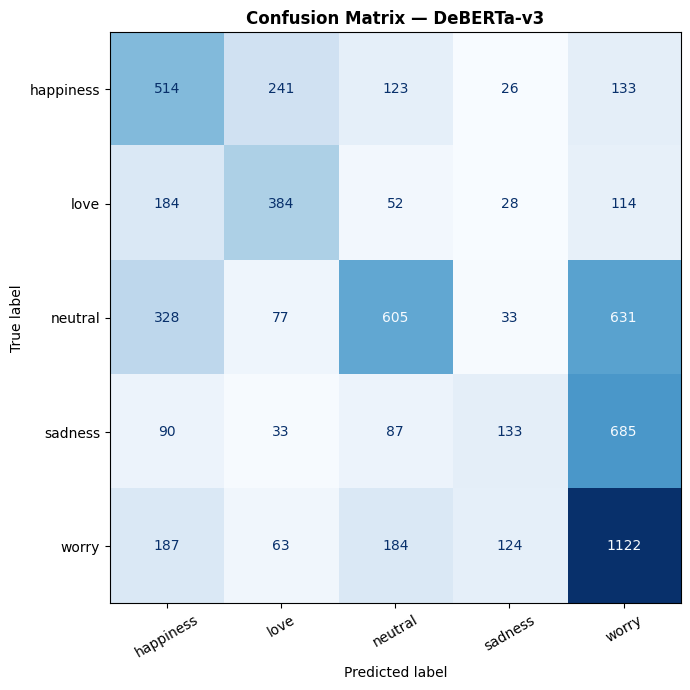

In [ ]:
ckpt   = torch.load(f"{CFG.save_dir}_best.pth", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])

y_pred = ckpt['val_preds'].argmax(axis=1)
y_true = ckpt['val_labels']

print("── Classification Report ──")
print(classification_report(y_true, y_pred,
                             target_names=le.classes_, digits=4))

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
ax.set_title('Confusion Matrix — DeBERTa-v3', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def predict_emotion(text: str) -> dict:
    model.eval()
    enc    = tokenizer(preprocess(text), return_tensors='pt',
                       truncation=True, max_length=256)
    ids    = enc['input_ids'].to(DEVICE)
    mask   = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        logits, _ = model(ids, mask)
    probs    = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_id  = int(probs.argmax())

    return {
        'label':         id2label[pred_id],
        'confidence':    float(probs[pred_id]),
        'probabilities': {id2label[i]: float(p) for i, p in enumerate(probs)}
    }

# Demo
demo_texts = [
    "I am so happy today, everything is going great!",
    "I'm really worried about the exam tomorrow.",
    "I love spending time with my family.",
    "This is the saddest day of my life.",
    "Nothing special happened today.",
]

for t in demo_texts:
    r = predict_emotion(t)
    print(f"Text      : {t}")
    print(f"Prediction: {r['label']}  (confidence: {r['confidence']:.3f})\n")

Text      : I am so happy today, everything is going great!
Prediction: love  (confidence: 0.665)

Text      : I'm really worried about the exam tomorrow.
Prediction: worry  (confidence: 0.586)

Text      : I love spending time with my family.
Prediction: love  (confidence: 0.913)

Text      : This is the saddest day of my life.
Prediction: sadness  (confidence: 0.491)

Text      : Nothing special happened today.
Prediction: worry  (confidence: 0.594)

